# Table of Contents

1. [Configuration-, Work- and Task Spaces](#configuration-work-and-task-spaces)
   - [Example: Double Pendulum](#example-double-pendulum)
   - [Example: Constrained Double Pendulum](#example-constrained-double-pendulum)
   - [Example: CartPole](#example-cartpole)
2. [2D Rigid Body](#2d-rigid-body)
   - [Translations](#translations)
   - [Rotations](#rotations)
   - [Homogeneous Coordinates](#homogeneous-coordinates)
   - [Euclidean](#euclidean)
   - [Example: SE(2) action in homogeneous coordinates](#example-se2-action-in-homogeneous-coordinates)
   - [Lie Algebras](#lie-algebras)
   - [Trajectories in SE(2)](#trajectories-in-se2)
3. [3D Rigid Body](#3d-rigid-body)
   - [Euler Angles](#euler-angles)
   - [Gimbal Lock](#gimbal-lock)
   - [Quaternions](#quaternions)
   - [Why there is gimbal lock: 2D visual intuitions](#why-there-is-gimbal-lock-2d-visual-intuitions)
   - [so(3): Lie Algebra of SO(3)](#so3-lie-algebra-of-so3)
   - [Conversions](#conversions)
   - [Screw motion](#screw-motion)
   - [se(3): Lie Algebra of SE(3), Twists, and the Adjoint](#se3-lie-algebra-of-se3-twists-and-the-adjoint)
4. [Links and Joints, Forward Kinematics](#links-and-joints-forward-kinematics)
   - [Table of joint types](#table-of-joint-types)
   - [Denavit-Hartenberg](#denavit-hartenberg)
   - [Exponential representation](#exponential-representation)
   - [Kinematic chain](#kinematic-chain)
   - [URDF examples](#urdf-examples)
5. [Inverse Kinematics](#inverse-kinematics)
   - [Jacobian computation](#jacobian-computation)
   - [Newton-Raphson](#newton-raphson)

In [1]:
%matplotlib widget
import sys
from pathlib import Path

_seminar_dir = Path.cwd()
if str(_seminar_dir) not in sys.path:
    sys.path.insert(0, str(_seminar_dir))

import numpy as np
from scipy.spatial.transform import Rotation
from IPython.display import display


from lib.rotations import euler_zyx, matrix_log_so3
from lib.double_pendulum_viz import (
    show_double_pendulum_interactive,
    show_constrained_double_pendulum_interactive,
)
from lib.torus_workspace_mapping_viz import plot_torus_workspace_mapping
from lib.cartpole_viz import show_cartpole_interactive
from lib.se2_homogeneous_viz import show_se2_homogeneous_interactive
from lib.se2_trajectory_viz import show_se2_drift_trajectory
from lib.rigid_body_3d_viz import (
    show_so3_euler_interactive,
    show_gimbal_lock_interactive,
    show_axis_angle_interactive,
    show_se3_interactive,
    show_screw_motion_interactive,
)
from lib.no_gimbal_lock_viz import coordinate_singularity
from lib.joint_viz_threejs import embed_all_joints
from lib.so101_viz import show_so101_interactive
from lib.so101_ik_viz import show_so101_ik_demo
import pytorch_kinematics as pk

_Material in this Jupyter notebook closely follows "Modern Robotics..." by Kevin M. Lynch and Frank C. Park, with some minor transpositions in order of definitions introduced, and can be read along the book, used to play around with concepts and gain visual intuition behind those. ‒ Andrei_

---
## Configuration-, Work- and Task Spaces

Key notions:

* __Configuration Space__ — set of all possible configurations of the body/mechanism/robot, most of the times, this set has a nice structure (manifold, or even a Lie group).

* __End-effector__ — particular point/link/attachment on the robot, usually the one that performs the task.

* __Task Space__ — set of all possible task-related configurations of the end-effector or of positions of relevant robot parts, e.g. position and orientation of scalpel for surgical robot, or grasping configurations of a human hand around the cup, usually a subset of $\mathbb{R}^n$. Sometimes there are more than one configurations of robot that achieve specific end-effector configuration, and sometimes there is none.

* __Work Space__ — set of all reachable positions of the end-effector, usually a subset of $\mathbb{R}^n$.

### Example: Double Pendulum

Click on the workspace of the pendulum to move it there (it will be the first appearance of __inverse kinematics__ problem). Or click on configuration to choose pair of angles $\theta_1$ and $\theta_2$ (it will be the first appearance of __forward kinematics__ problem).

Notice how there are two possible configurations for the same end-effector position. Some points in configuration space map end-effector to the same position.

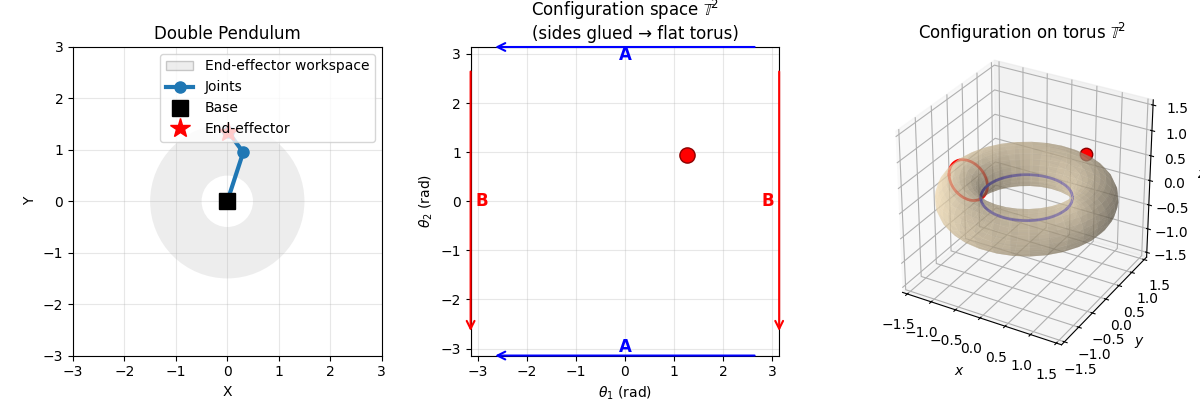

In [2]:
L1, L2 = 1.0, 0.5
show_double_pendulum_interactive(L1, L2, np.array([0.4 * np.pi, 0.3 * np.pi]))

In [ ]:
plot_torus_workspace_mapping(L1=1.0, L2=0.5, n_circles=20)

### Example: Constrained Double Pendulum

Same as the double pendulum but $\theta_1 \in [-\pi, 0]$ (first joint constrained, bottom semicircle only). Configuration space is a half torus. What is the kinematics mapping now? 

In [ ]:
show_constrained_double_pendulum_interactive(L1, L2, np.array([-0.4 * np.pi, 0.6 * np.pi]))

### Example: CartPole

Configuration space is position $x$ and angle $\theta$: $\mathbb{R} \times S^1$ (infinite cylinder). Once again we have two-point symmetry and an exercise for you is to understand how configuration space is doubly covering the workspace.

In [ ]:
show_cartpole_interactive(np.array([0.0, 0.3 * np.pi]), pole_len=0.5)

<div style="text-align: center;">
  <img src="assets/cartesian_family.jpg" alt="Cartesian Family" style="max-width: 600px; width: 100%;" />
</div>

---
## 2D Rigid Body

A **rigid body** in the plane is an object whose points keep fixed distances and angles; only position and orientation can change. The set of all such transformations is the **2D Euclidean group** $\mathrm{SE}(2)$. It is built from **translations** and **rotations**.

### Translations

**Translation** by a vector $d = (d_x, d_y) \in \mathbb{R}^2$ moves every point $p$ to $p' = p + d$. The set of all 2D translations is $\mathbb{R}^2$ with addition. Translations preserve distances and orientations (no rotation).

### Rotations

**Rotation** about the origin by angle $\theta$ (counterclockwise) is a linear map given by the matrix
$$
R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}.
$$
These matrices form the **special orthogonal group** $\mathrm{SO}(2)$: $2\times 2$ matrices with $R^\top R = I$ and $\det R = 1$. So $\mathrm{SO}(2)$ is the group of 2D rotations (one DOF: $\theta \in S^1$).

The defining identities imply preservation of the **Euclidean metric**. For any vectors $p, q \in \mathbb{R}^2$, the condition $R^\top R = I$ gives
$$
\langle R p,\, R q \rangle = (R p)^\top (R q) = p^\top R^\top R\, q = p^\top q = \langle p,\, q \rangle.
$$
So the dot product, and hence lengths $\|R p\| = \|p\|$ and angles, via $\alpha = \arccos\left(\frac{\langle p, q \rangle}{\|p\| \|q\|}\right)$, are preserved. The condition $\det R = 1$ restricts to **proper** rotations (orientation preserved); $\det R = -1$ would give a reflection, which also preserves the metric but reverses orientation.

### Homogeneous Coordinates

To **combine** rotation and translation in one operation we use **homogeneous coordinates**. A point $p = (x, y) \in \mathbb{R}^2$ is represented as $\tilde{p} = (x, y, 1)^\top$. A **rigid transformation** (rotation $R \in \mathrm{SO}(2)$ and translation $d \in \mathbb{R}^2$) is encoded as a $3\times 3$ matrix
$$
T = \begin{bmatrix} R & d \\ 0 & 1 \end{bmatrix} = \begin{bmatrix} \cos\theta & -\sin\theta & d_x \\ \sin\theta & \cos\theta & d_y \\ 0 & 0 & 1 \end{bmatrix}.
$$
Then the transformed point is $\tilde{p}' = T \tilde{p}$: the top two components are $p' = R p + d$. So: first rotate, then translate. Composition of two rigid motions is matrix multiplication: $T_{ac} = T_{ab} T_{bc}$.

Here’s how the homogeneous transform acts on the 3D basis vectors.

The 3D homogeneous space has standard basis
$$
\mathbf{e}_x = \begin{pmatrix} 1 \\ 0 \\ 0 \end{pmatrix}, \quad
\mathbf{e}_y = \begin{pmatrix} 0 \\ 1 \\ 0 \end{pmatrix}, \quad
\mathbf{e}_w = \begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}.
$$

**Action on basis vectors.**

The SE(2) matrix is
$$
T = \begin{bmatrix} R & d \\ 0^\top & 1 \end{bmatrix}
= \begin{bmatrix} \cos\theta & -\sin\theta & d_x \\ \sin\theta & \cos\theta & d_y \\ 0 & 0 & 1 \end{bmatrix}, \quad
R \in \mathrm{SO}(2), \quad d = \begin{pmatrix} d_x \\ d_y \end{pmatrix} \in \mathbb{R}^2.
$$

$T$ acts by matrix multiplication; the images of the basis vectors are the columns of $T$:
$$
T\,\mathbf{e}_x = T\begin{pmatrix} 1 \\ 0 \\ 0 \end{pmatrix}
= \begin{pmatrix} R_{11} \\ R_{21} \\ 0 \end{pmatrix}
= \begin{pmatrix} \cos\theta \\ \sin\theta \\ 0 \end{pmatrix},
$$
$$
T\,\mathbf{e}_y = T\begin{pmatrix} 0 \\ 1 \\ 0 \end{pmatrix}
= \begin{pmatrix} R_{12} \\ R_{22} \\ 0 \end{pmatrix}
= \begin{pmatrix} -\sin\theta \\ \cos\theta \\ 0 \end{pmatrix},
$$
$$
T\,\mathbf{e}_w = T\begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}
= \begin{pmatrix} d \\ 1 \end{pmatrix}
= \begin{pmatrix} d_x \\ d_y \\ 1 \end{pmatrix}.
$$
Thus, the plane at $w=1$ is transformed according to $p' = R p + d$.

### Euclidean

The **2D Euclidean group** $\mathrm{SE}(2)$ is the set of all rigid motions (rotations + translations) with composition as the group operation. As matrices:
$$
\mathrm{SE}(2) = \left\{ T = \begin{bmatrix} R & d \\ 0 & 1 \end{bmatrix} : R \in \mathrm{SO}(2),\; d \in \mathbb{R}^2 \right\}.
$$
It is the **semidirect product** $\mathrm{SO}(2) \ltimes \mathbb{R}^2$. Inverse:
$$
T^{-1} = \begin{bmatrix} R^\top & -R^\top d \\ 0 & 1 \end{bmatrix}
$$
(inverse rotation, then inverse translation in the rotated frame).

### Example: SE(2) action in homogeneous coordinates
Use the sliders to change translation $(x, y)$ and rotation $\theta$. The gray frame is the reference (identity); the blue frame is its image under $T(x, y, \theta)$ on the plane $w = 1$.

In [ ]:
show_se2_homogeneous_interactive()

### Lie Algebras

**Tangent space and the Lie algebra.** For a matrix Lie group $G$ (e.g. $\mathrm{SO}(2)$ or $\mathrm{SE}(2)$), the **Lie algebra** $\mathfrak{g}$ is the **tangent space to $G$ at the identity**, $T_e G$. Concretely: take smooth curves $t \mapsto g(t) \in G$ with $g(0) = I$. The derivative $\dot g(0)$ is a tangent vector; the set of all such derivatives is $\mathfrak{g}$. So the Lie algebra is the vector space of "infinitesimal" motions at the identity. We write $\mathfrak{so}(2)$ for the Lie algebra of $\mathrm{SO}(2)$ and $\mathfrak{se}(2)$ for the Lie algebra of $\mathrm{SE}(2)$. The space $\mathfrak{g}$ is a vector space whose dimension equals the dimension of $G$ (as a manifold): $\dim \mathfrak{so}(2) = 1$ and $\dim \mathfrak{se}(2) = 3$. It is equipped with a **Lie bracket** $[A, B] = AB - BA$ (for matrix groups) that makes it a Lie algebra; for 2D we will keep formulas explicit without emphasizing the bracket. In 2D we write the algebra matrix as $\widehat{\xi}$; in 3D we use $[\omega]_\times$ for $\mathfrak{so}(3)$ and $[S]$ for $\mathfrak{se}(3)$.


**$\mathfrak{so}(2)$.** Any curve in $\mathrm{SO}(2)$ has the form $R(\theta(t))$ with
$$
R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}.
$$
By the chain rule, $\dot R = \frac{dR}{d\theta}\,\dot\theta$. One checks that $\frac{dR}{d\theta} = \Omega R(\theta)$, so $\dot R = \Omega R(\theta)\,\dot\theta$. At $t = 0$ with $\theta(0) = 0$ we have $R(0) = I$, hence $\dot R(0) = \dot\theta(0)\, \Omega$, where
$$
\Omega = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix}.
$$
So $\mathfrak{so}(2) = \{ \omega \Omega : \omega \in \mathbb{R} \}$: a one-dimensional vector space. Every element is a **skew-symmetric** $2\times 2$ matrix ($X^\top = -X$).


**$\mathfrak{se}(2)$.** The tangent space to $\mathrm{SE}(2)$ at $I_3$ comes from curves $T(t) = \begin{bmatrix} R(t) & d(t) \\ 0 & 1 \end{bmatrix}$ with $T(0) = I$. Then
$$
\dot T(0) = \begin{bmatrix} \dot R(0) & \dot d(0) \\ 0 & 0 \end{bmatrix} = \begin{bmatrix} \omega\Omega & v \\ 0 & 0 \end{bmatrix}, \quad \omega \in \mathbb{R},\; v \in \mathbb{R}^2.
$$
So $\mathfrak{se}(2)$ is the set of $3\times 3$ matrices of that block form: a $2\times 2$ skew block (angular part) and a translation vector $v$. We often write an element as the pair $(\omega, v)$ or as the matrix $\widehat{\xi}$ with that block structure. The **hat map** $(\omega, v) \mapsto \widehat{\xi}$ sends the 3-vector of coordinates to the $3\times 3$ matrix in $\mathfrak{se}(2)$.

**Connection to velocities.** If $R(t)$ is a path in $\mathrm{SO}(2)$, then $\dot R(t) = \dot\theta(t)\, \Omega\, R(t)$, so with $\omega = \dot\theta$ we have $\dot R = \omega\, \Omega\, R$. The scalar $\omega$ is the **body angular velocity**; the algebra element at time $t$ is $\omega(t)\Omega$. So the tangent vector at $R(t)$ is $\omega\Omega R(t)$, i.e. the left-translate of $\omega\Omega$ from the identity to $R(t)$; the algebra element $\omega\Omega$ is the velocity "in the body frame."

For a rigid motion $T(t) \in \mathrm{SE}(2)$, $\dot T(t)$ has the form $\widehat{\xi}(t)\, T(t)$ for some $\widehat{\xi}(t) \in \mathfrak{se}(2)$: the tangent vector at $T(t)$ is the left-translate of $\widehat{\xi}(t)$ from the identity, so we say the twist is in the **body** frame. The twist $(\omega(t), v(t))$ encodes angular and translational velocity: $\omega$ is the body angular velocity; in the body frame, $v$ is the velocity of the origin expressed in body coordinates. In the **spatial** frame the same motion is represented by a different twist (fixed-frame coordinates). Either way, the pair $(\omega, v)$ is the coordinate representation of an element of $\mathfrak{se}(2)$.


**From group identities to algebra identities.** The group $\mathrm{SO}(2)$ satisfies $R^\top R = I$ and $\det R = 1$. Differentiate $R(t)^\top R(t) = I$ at $t = 0$ with $R(0) = I$: we get $\dot R(0)^\top + \dot R(0) = 0$, so every tangent vector at the identity is **skew-symmetric**. That is exactly $\mathfrak{so}(2)$. Differentiating $\det R(t) = 1$ gives $\mathrm{tr}(\dot R(0)) = 0$; for $2\times 2$ skew matrices this holds automatically.

For $\mathrm{SE}(2)$, the bottom row of $T$ is $(0, 0, 1)$. Differentiating at $t = 0$ with $T(0) = I$ forces the bottom row of $\dot T(0)$ to be zero, which matches the block form of $\mathfrak{se}(2)$. The top-left $2\times 2$ block of $\dot T(0)$ is in $\mathfrak{so}(2)$, and the top-right block is an arbitrary vector in $\mathbb{R}^2$. So the group identities force tangent vectors to lie in the expected subspaces and confirm $\dim \mathfrak{so}(2) = 1$ (one parameter $\omega$) and $\dim \mathfrak{se}(2) = 3$ ($\omega$ plus two for $v$).


**Exponential map via differential equation integration.** The map $\exp \colon \mathfrak{g} \to G$ sends an algebra element to the group by **integrating the ODE** whose right-hand side is that element (the infinitesimal generator).

**SO(2):** For any algebra element $\theta \Omega \in \mathfrak{so}(2)$ (one real parameter $\theta$), define $R(\tau)$ as the solution of
$$
\frac{dR}{d\tau} = (\theta \Omega)\, R, \quad R(0) = I.
$$
With $\sigma = \theta \tau$, this becomes $\frac{dR}{d\sigma} = \Omega R$, whose solution with $R(0) = I$ is the rotation by angle $\sigma$. At $\tau = 1$ we have $\sigma = \theta$, so $R(1) = R(\theta)$. Thus $\exp(\theta \Omega) = R(\theta)$ for any $\theta \in \mathbb{R}$, the same rotation matrix as in the Rotations section.


**SE(2):** For $\widehat{\xi} \in \mathfrak{se}(2)$ (matrix with block $\omega\Omega$ and $v$), define $T(\tau)$ by
$$
\frac{dT}{d\tau} = \widehat{\xi}\, T, \quad T(0) = I.
$$
(This uses the **body** twist: the constant $\widehat{\xi}$ is the velocity in the body frame.) The solution at $\tau = 1$ is $T = \exp(\widehat{\xi})$. Writing $T = \begin{bmatrix} R & d \\ 0 & 1 \end{bmatrix}$, the block product $\widehat{\xi}\, T = \begin{bmatrix} \omega\Omega & v \\ 0 & 0 \end{bmatrix} \begin{bmatrix} R & d \\ 0 & 1 \end{bmatrix}$ gives $\frac{dR}{d\tau} = \omega\Omega R$ and $\frac{dd}{d\tau} = \omega\Omega\, d + v$. The rotation part is $R(\theta) = \exp(\theta \Omega)$ with $\theta = \omega$ when $\tau = 1$. The translation part $d$ satisfies $d(0)=0$; integrating $\frac{dd}{d\tau} = \omega\Omega\, d + v$ yields $d(1) = \int_0^1 R(\omega\tau)\, v\, d\tau$. When $\omega \neq 0$, this gives $d = \frac{1}{\omega}\begin{bmatrix} \sin\theta & -(1-\cos\theta) \\ 1-\cos\theta & \sin\theta \end{bmatrix} v$ with $\theta = \omega$; when $\omega = 0$ (pure translation), $\frac{dd}{d\tau} = v$ so $d(1) = v$. Thus
$$
\exp(\widehat{\xi}) = \begin{bmatrix} R(\theta) & d \\ 0 & 1 \end{bmatrix}, \quad \theta = \omega,\quad d = \begin{cases} \frac{1}{\omega}\begin{bmatrix} \sin\theta & -(1-\cos\theta) \\ 1-\cos\theta & \sin\theta \end{bmatrix} v & \omega \neq 0 \\ v & \omega = 0 \end{cases}
$$


**Logarithm map.** The map $\log \colon G \to \mathfrak{g}$ is the inverse of $\exp$ (where defined): $\log(g)$ is the algebra element $\widehat{\xi}$ such that $\exp(\widehat{\xi}) = g$.

**SO(2):** Given $R(\theta)$, we recover $\theta \in (-\pi, \pi]$ (or any interval of length $2\pi$) so that $\log(R) = \theta\Omega$. For example, $\theta = \mathrm{atan2}(R_{21}, R_{11})$ using the $(2,1)$ and $(1,1)$ entries of $R$, or $\theta = \arccos\bigl((\mathrm{tr}(R)-1)/2\bigr)$ with sign from the skew part $R_{21} - R_{12}$.

**SE(2):** Given $T = \begin{bmatrix} R & d \\ 0 & 1 \end{bmatrix}$, recover $(\omega, v)$ so that $\exp(\widehat{\xi}) = T$. First, $\theta = \log R$ as above (so $\omega = \theta$). If $\theta \not\equiv 0 \pmod{2\pi}$, the translation matrix $A(\theta) = \frac{1}{\theta}\begin{bmatrix} \sin\theta & -(1-\cos\theta) \\ 1-\cos\theta & \sin\theta \end{bmatrix}$ (with $\omega = \theta$) is invertible (determinant $\propto 1-\cos\theta$ is nonzero), so $v = A(\theta)^{-1} d$. If $\theta \equiv 0 \pmod{2\pi}$ then $R = I$ (pure translation); we take $\omega = 0$ and $v = d$. So $\widehat{\xi}$ is uniquely determined by $T$ (for $\theta \in (-\pi,\pi]$ the logarithm is single-valued).


### Trajectories in SE(2)

A trajectory in $\mathrm{SE}(2)$ is obtained by **integrating body twists** $(\omega, v) \in \mathfrak{se}(2)$. For a piecewise-constant twist over a segment of duration $\Delta\tau$, the ODE $\frac{dT}{d\tau} = \widehat{\xi}\, T$ with $T(0) = T_{\mathrm{init}}$ has solution $T(\tau) = T_{\mathrm{init}}\, \exp(\widehat{\xi}\, \tau)$ (body frame). So over one segment, $T(\Delta\tau) = T_{\mathrm{init}}\, \exp(\widehat{\xi})$ with $\theta = \omega$, $d$ as in the SE(2) exponential formula above. The viz builds the trajectory from a sequence of segments $(\Delta\tau_i, \omega_i, v_i)$: at segment boundaries it updates $T \leftarrow T\, \exp(\widehat{\xi}_i)$ (i.e. $\mathrm{se2\_exp}(\omega_i, v_i, 1)$), and at sample times $\tau$ within a segment it uses $T(\tau) = T\, \exp(\widehat{\xi}_i\, s)$ with $s = (\tau - \tau_{\mathrm{prev}})/\Delta\tau_i \in [0,1]$. So the path is the composition of these exponentials from the initial pose $T_{\mathrm{init}}$.

In [ ]:
show_se2_drift_trajectory()

<div style="text-align: center;">
  <img src="assets/drift.gif" alt="Drift" style="max-width: 500px; width: 100%;" />
</div>

---
## 3D Rigid Body

A **rigid body** in 3D is an object whose points keep fixed distances and angles; only position and orientation change. The configuration is given by $(R, p)$ with $R \in \mathrm{SO}(3)$ and $p \in \mathbb{R}^3$.

**SO(3)** — the **special orthogonal group** — is the set of all $3\times 3$ rotation matrices satisfying $R^\top R = I$ and $\det R = 1$. It is a Lie group of dimension 3. Metric preservation follows: $\langle R u,\, R v \rangle = \langle u,\, v \rangle$ (lengths and angles preserved); $\det R = 1$ restricts to proper rotations (no reflection).

**SE(3)** — the **special Euclidean group** — is the set of all rigid motions, represented as $4\times 4$ matrices
$$
T = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix}, \quad R \in \mathrm{SO}(3),\; p \in \mathbb{R}^3.
$$
Action on a point: $p' = R\, p + p_{\text{trans}}$ (rotation then translation; $p_{\text{trans}}$ is the translation block of $T$). Composition is matrix multiplication; the inverse is
$$
T^{-1} = \begin{bmatrix} R^\top & -R^\top p \\ 0 & 1 \end{bmatrix}.
$$


### Euler Angles

Euler angles build a 3D rotation by composing three elementary rotations about body (or fixed) axes. Many conventions exist (ZYX, ZYZ, etc.); a common one in robotics is **ZYX (roll–pitch–yaw)**:
$$
R = R_z(\alpha)\, R_y(\beta)\, R_x(\gamma).
$$
The elementary rotation matrices (with $c = \cos$, $s = \sin$) are
$$
R_x(\gamma) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & c_\gamma & -s_\gamma \\ 0 & s_\gamma & c_\gamma \end{bmatrix}, \quad
R_y(\beta) = \begin{bmatrix} c_\beta & 0 & s_\beta \\ 0 & 1 & 0 \\ -s_\beta & 0 & c_\beta \end{bmatrix}, \quad
R_z(\alpha) = \begin{bmatrix} c_\alpha & -s_\alpha & 0 \\ s_\alpha & c_\alpha & 0 \\ 0 & 0 & 1 \end{bmatrix}.
$$
The full rotation is then $R = R_z(\alpha)\, R_y(\beta)\, R_x(\gamma)$ (applied right-to-left: first $R_x(\gamma)$, then $R_y(\beta)$, then $R_z(\alpha)$).

At $\beta = \pm\pi/2$ the ZYX Euler representation becomes singular (**gimbal lock**); see the *Gimbal Lock* section below.

Use the sliders to change Euler angles α, β, γ. **Red/green/blue** axes: reference (identity). **Magenta/yellow/cyan** axes: rotated by $R_z(\alpha)R_y(\beta)R_x(\gamma)$.

In [ ]:
show_so3_euler_interactive()

### Gimbal Lock

When $\beta = \pm\pi/2$ in the ZYX Euler convention, the axes of the first rotation ($R_z$) and the third ($R_x$, applied in the body after $R_y$) align. The composition then depends only on the sum $\alpha + \gamma$: one degree of freedom is lost, and $R$ is unchanged under $(\alpha,\gamma) \mapsto (\alpha + \delta, \gamma - \delta)$. Explicitly, for $\beta = \pi/2$ we have
$$
R = R_z(\alpha)\, R_y(\pi/2)\, R_x(\gamma) = R_z(\alpha+\gamma)\, R_y(\pi/2),
$$
so the third column of $R$ is $\bigl(\sin(\alpha+\gamma),\, -\cos(\alpha+\gamma),\, 0\bigr)^\top$.

**Demo:** β is fixed at $+\pi/2$ or $-\pi/2$; vary α and γ with the sliders. The **magenta/yellow/cyan** frame is $R = R_z(\alpha)R_y(\beta)R_x(\gamma)$. The title shows $\alpha+\gamma$; different pairs $(\alpha,\gamma)$ with the same sum give the same orientation.

In [ ]:
show_gimbal_lock_interactive()

**Apollo 11 and gimbal lock.** The lunar module used a 3-gimbal IMU; engineers skipped a fourth gimbal for simplicity and reliability. Near 85° pitch the software warned at 70° and then **froze** the platform at 85°—no unwinding, just stop. The crew had to move the spacecraft away by hand and realign using the stars. Michael Collins, in the command module, later joked: *"How about sending me a fourth gimbal for Christmas?"*

<div style="text-align: center;">
  <img src="assets/No_gimbal_lock.png" alt="No gimbal lock" style="max-width: 400px; width: 100%;" />
  <img src="assets/Gimbal_lock.png" alt="Gimbal lock" style="max-width: 400px; width: 100%;" />
</div>

### Quaternions

A **unit quaternion** $q = (q_w, q_x, q_y, q_z)$ represents a rotation when $q_w^2 + q_x^2 + q_y^2 + q_z^2 = 1$. The scalar part is $q_w$; the vector part is $\vec{q} = (q_x, q_y, q_z)$.

**Rotating a vector**: For $v \in \mathbb{R}^3$, the rotated vector is $v' = q \odot v \odot q^{-1}$ (quaternion product with $v$ treated as pure quaternion $(0, v)$). Equivalently one converts $q$ to a $3\times 3$ rotation matrix $R(q)$; the standard formula in terms of $q_w, q_x, q_y, q_z$ yields $R$ so that $v' = R\, v$.

**Properties**: Unit quaternions form a double cover of SO(3): $q$ and $-q$ give the same $R$. There is no gimbal lock. **Slerp** (spherical linear interpolation) gives smooth interpolation between two rotations.

### Why there is gimbal lock: 2D visual intuitions

In [ ]:
coordinate_singularity()

### so(3): Lie Algebra of SO(3)

The **Lie algebra** $\mathfrak{so}(3)$ is the tangent space to $\mathrm{SO}(3)$ at the identity. Take any smooth curve $t \mapsto R(t) \in \mathrm{SO}(3)$ with $R(0) = I$. The derivative $\dot R(0)$ is a tangent vector; the set of all such derivatives is $\mathfrak{so}(3)$.

**From group identities to algebra.** Differentiate $R(t)^\top R(t) = I$ at $t = 0$ with $R(0) = I$: we get $\dot R(0)^\top + \dot R(0) = 0$, so every tangent vector at the identity is **skew-symmetric**. Differentiating $\det R(t) = 1$ gives $\mathrm{tr}(\dot R(0)) = 0$; for $3\times 3$ skew matrices this holds automatically. So $\mathfrak{so}(3)$ is the vector space of skew-symmetric $3\times 3$ matrices, and $\dim \mathfrak{so}(3) = 3$.

**Hat map.** For $\omega = (\omega_x, \omega_y, \omega_z)^\top \in \mathbb{R}^3$ we define the **hat map** $\omega \mapsto [\omega]_\times \in \mathfrak{so}(3)$ by
$$
[\omega]_\times = \begin{bmatrix} 0 & -\omega_z & \omega_y \\ \omega_z & 0 & -\omega_x \\ -\omega_y & \omega_x & 0 \end{bmatrix}.
$$
One verifies $[\omega]_\times v = \omega \times v$ (cross product) for any $v \in \mathbb{R}^3$. The inverse **vee map** $[\cdot]_\times^{-1}$ sends a skew matrix back to the 3-vector $\omega$.

**Axis–angle and exponential coordinates.** Rotating by angle $\theta$ about a unit axis $\hat{\omega}$ corresponds to the algebra element $\theta \hat{\omega}$: direction = axis, magnitude = angle. So $\omega = \theta \hat{\omega}$ are the **exponential coordinates** for SO(3).


**Exponential map via ODE.** For $\widehat{\omega} = [\omega]_\times \in \mathfrak{so}(3)$, define $R(\tau)$ as the solution of
$$
\frac{dR}{d\tau} = \widehat{\omega}\, R, \quad R(0) = I.
$$
The solution at $\tau = 1$ is $\exp([\omega]_\times)$. A key identity is $[\hat{\omega}]_\times^3 = -[\hat{\omega}]_\times$ for unit $\hat{\omega}$. Using $\theta = \|\omega\|$ and $\hat{\omega} = \omega/\theta$ when $\omega \neq 0$, the Taylor series $\exp([\omega]_\times) = I + [\omega]_\times + \frac{1}{2!}[\omega]_\times^2 + \cdots$ collapses to the **Rodrigues formula**:
$$
R = I + \sin\theta\, [\hat{\omega}]_\times + (1-\cos\theta)\, [\hat{\omega}]_\times^2, \quad \theta = \|\omega\|,\ \hat{\omega} = \omega/\theta.
$$
For $\omega = 0$ we have $\exp(0) = I$.


**Logarithm map.** Given $R \in \mathrm{SO}(3)$, recover $\omega$ such that $\exp([\omega]_\times) = R$. For $R \neq I$, set $\theta = \arccos\bigl((\mathrm{tr}(R)-1)/2\bigr) \in (0, \pi)$. Then $\sin\theta \neq 0$ and the axis is
$$
\hat{\omega} = \frac{1}{2\sin\theta} \begin{pmatrix} R_{32}-R_{23} \\ R_{13}-R_{31} \\ R_{21}-R_{12} \end{pmatrix},
$$
so $\omega = \theta \hat{\omega}$. For $R = I$ take $\omega = 0$. For $\theta = \pi$ (rotation by $\pi$), $R$ is symmetric and the axis is any unit eigenvector with eigenvalue $+1$; the formula $(R - R^\top)/(2\sin\theta)$ is not defined, so one recovers $\hat{\omega}$ from the diagonal of $R$ (e.g. $\hat{\omega}_i = \sqrt{(R_{ii}+1)/2}$ with correct sign from off-diagonals).

Use sliders to set the rotation axis (ωx, ωy, ωz, normalized) and angle θ. The colored frame is $R = \mathrm{Rodrigues}(\hat{\omega}, \theta)$.

In [ ]:
show_axis_angle_interactive()

Use sliders to set translation (px, py, pz) and Euler angles. World frame at origin; second frame at $p$ with orientation $R(\alpha,\beta,\gamma)$.

In [ ]:
show_se3_interactive()

### Conversions

| From | To | Formula |
|------|----|---------|
| Euler ZYX $(\alpha,\beta,\gamma)$ | $R$ | $R = R_z(\alpha)\, R_y(\beta)\, R_x(\gamma)$ (product of elementary rotations in the chosen convention) |
| $R$ | Euler ZYX | Solve $R = R_z(\alpha)\, R_y(\beta)\, R_x(\gamma)$ for $(\alpha,\beta,\gamma)$ from the entries of $R$ (e.g. $\beta = \arcsin(-R_{31})$, then $\alpha = \mathrm{atan2}(R_{32}/c_\beta, R_{33}/c_\beta)$, $\gamma = \mathrm{atan2}(R_{21}/c_\beta, R_{11}/c_\beta)$ when $c_\beta \neq 0$) |
| $R$ | Axis–angle $\omega$ | $\omega = \theta \hat{\omega}$ with $\theta = \arccos\bigl((\mathrm{tr}(R)-1)/2\bigr)$ and $\hat{\omega}$ from $(R - R^\top)/(2\sin\theta)$ (see logarithm map for SO(3)) |
| Axis–angle | $R$ | Rodrigues: $R = I + \sin\theta\, [\hat{\omega}]_\times + (1-\cos\theta)\, [\hat{\omega}]_\times^2$ |
| $R$ | Quaternion $(q_w,q_x,q_y,q_z)$ | Standard formula: $q_w = \frac{1}{2}\sqrt{1+\mathrm{tr}(R)}$, then $q_x,q_y,q_z$ from the antisymmetric part (with sign and normalization) |
| Quaternion | $R$ | Standard formula in terms of $q_w, q_x, q_y, q_z$ so that $v' = R\, v$ equals $q \odot (0,v) \odot q^{-1}$ |
| Axis–angle | Quaternion | Via $R$: axis–angle $\to$ $R$ (Rodrigues) $\to$ quaternion; or directly $q = (\cos(\theta/2), \hat{\omega}\sin(\theta/2))$ |

A small numerical example below converts one rotation from Euler to $R$, quaternion, and axis–angle.

In [ ]:
alpha, beta, gamma = 0.2, 0.5, 0.3
R = euler_zyx(alpha, beta, gamma)
r = Rotation.from_matrix(R)
quat_xyzw = r.as_quat()
omega_hat, theta = matrix_log_so3(R)
rotvec = omega_hat * theta if theta > 1e-10 else np.zeros(3)

print("Euler ZYX (rad):", (alpha, beta, gamma))
print("R (3x3):\n", R)
print("Quaternion (xyzw):", np.round(quat_xyzw, 4))
print("Axis-angle (rotvec):", np.round(rotvec, 4), "  |angle| =", round(theta, 4))

### Screw motion

**Chasles' theorem.** Every rigid body displacement in 3D can be realized as a rotation about a unique line in space plus a translation along that same line. Such a motion is called a **screw motion**.

**Screw axis.** A **screw axis** is determined by: a **direction** $\hat{\omega} \in \mathbb{R}^3$ (unit vector), a **point** $q$ on the line (so the line is $\{ q + \lambda \hat{\omega} : \lambda \in \mathbb{R} \}$), and a **pitch** $h \in \mathbb{R}$: the distance translated along the axis per radian of rotation. **Pure rotation** has pitch $h = 0$. **Pure translation** corresponds to $\omega = 0$ (no rotation); the axis is then interpreted as a direction $\hat{v}$ in space, and the motion is translation along that line (axis at infinity).

**Twist from screw.** A **twist** (instantaneous rigid velocity) is a 6-vector $\mathcal{V} = (\omega, v)$: angular velocity $\omega \in \mathbb{R}^3$ and linear velocity $v \in \mathbb{R}^3$. For a screw with direction $\hat{\omega}$, a point $q$ on the axis, and pitch $h$, the linear velocity at a point on the axis (due to rotation and translation along the axis) is $v = -\omega \times q + h\, \omega$. With $\|\omega\| = 1$ we get the **normalized twist** $S = (\hat{\omega},\, -\hat{\omega} \times q + h\, \hat{\omega})$. For pure translation, $S = (0, \hat{v})$ with $\|\hat{v}\| = 1$.

**Finite screw displacement.** A rigid motion along the screw by angle $\theta$ (and thus translation $h\theta$ along the axis) is given by $T = \exp([S]\, \theta)$, where $[S]$ is the $4\times 4$ matrix in $\mathfrak{se}(3)$ corresponding to the twist $S = (\omega, v)$. The rotation part is $R = \exp([\omega]_\times \theta)$ (Rodrigues); the translation part is $p = G(\omega)\, v$ with $\theta = \|\omega\|$, $\hat{\omega} = \omega/\theta$, and

$$
G = \theta\, I + (1-\cos\theta)\, [\hat{\omega}]_\times + (\theta - \sin\theta)\, [\hat{\omega}]_\times^2.
$$
When $\omega = 0$ (pure translation), $T(\theta)$ has $R = I$ and $p = v\, \theta$. So the screw motion from $0$ to $\Theta$ is the one-parameter subgroup $T(\theta) = \exp([S]\, \theta)$, $0 \le \theta \le \Theta$.



Use sliders to set the twist $S = (\omega, v)$ and the maximum angle θ. Frames along the screw $T(\theta) = \exp(S\,\theta)$ are drawn.

In [ ]:
show_screw_motion_interactive()

### se(3): Lie Algebra of SE(3), Twists, and the Adjoint

**Tangent space and $\mathfrak{se}(3)$.** The Lie algebra $\mathfrak{se}(3)$ is the tangent space to $\mathrm{SE}(3)$ at the identity. Take any smooth curve $t \mapsto T(t) = \begin{bmatrix} R(t) & p(t) \\ 0 & 1 \end{bmatrix} \in \mathrm{SE}(3)$ with $T(0) = I$. Then
$$
\dot T(0) = \begin{bmatrix} \dot R(0) & \dot p(0) \\ 0 & 0 \end{bmatrix}.
$$
The bottom row of $T$ is $(0,0,0,1)$, so the bottom row of $\dot T(0)$ is zero. We already know $\dot R(0) \in \mathfrak{so}(3)$, so $\dot R(0) = [\omega]_\times$ for some $\omega \in \mathbb{R}^3$, and $\dot p(0) = v \in \mathbb{R}^3$ is arbitrary. So $\mathfrak{se}(3)$ is the set of $4\times 4$ matrices of the form
$$
[S] = \begin{bmatrix} [\omega]_\times & v \\ 0 & 0 \end{bmatrix}, \quad \omega, v \in \mathbb{R}^3,
$$
often written as the 6-vector $S = (\omega, v)$. The **hat map** $S \mapsto [S]$ sends $(\omega, v)$ to this matrix; $\dim \mathfrak{se}(3) = 6$.

**Body twist and spatial twist.** For a rigid motion $T(t) \in \mathrm{SE}(3)$, the **body twist** is $\mathcal{V}_b = T^{-1} \dot T$, and the **spatial twist** is $\mathcal{V}_s = \dot T\, T^{-1}$. Both lie in $\mathfrak{se}(3)$. The body twist $(\omega_b, v_b)$ is the velocity expressed in the **moving frame**: $\omega_b$ is the angular velocity in body coordinates, and $v_b$ is the linear velocity of the origin (in body coordinates). The spatial twist $(\omega_s, v_s)$ is the same instantaneous motion expressed in the **fixed frame**. They are related by the **adjoint**: $\mathcal{V}_s = \mathrm{Ad}_T\, \mathcal{V}_b$.


**Exponential map via ODE.** For $[S] \in \mathfrak{se}(3)$ with $S = (\omega, v)$, define $T(\tau)$ by
$$
\frac{dT}{d\tau} = [S]\, T, \quad T(0) = I.
$$
Writing $T = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix}$, the block product gives $\frac{dR}{d\tau} = [\omega]_\times R$ and $\frac{dp}{d\tau} = [\omega]_\times p + v$. The rotation part is $R(\tau) = \exp([\omega]_\times \tau)$, so at $\tau = 1$, $R = \exp([\omega]_\times)$ (Rodrigues). The translation satisfies $p(0) = 0$ and $\frac{dp}{d\tau} = [\omega]_\times p + v$. For $\omega \neq 0$, with $\theta = \|\omega\|$ and $\hat{\omega} = \omega/\theta$, the solution at $\tau = 1$ is $p = G(\omega)\, v$, where
$$
G = \theta\, I + (1-\cos\theta)\, [\hat{\omega}]_\times + (\theta - \sin\theta)\, [\hat{\omega}]_\times^2.
$$
(One verifies this by differentiating and using $[\hat{\omega}]_\times^3 = -[\hat{\omega}]_\times$.) For $\omega = 0$ (pure translation), $\frac{dp}{d\tau} = v$ so $p(1) = v$. Thus
$$
\exp([S]) = \begin{bmatrix} \exp([\omega]_\times) & G(\omega)\, v \\ 0 & 1 \end{bmatrix}, \quad \omega \neq 0; \qquad \exp([S]) = \begin{bmatrix} I & v \\ 0 & 1 \end{bmatrix}, \quad \omega = 0.
$$


**Logarithm map for SE(3).** Given $T = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix}$, recover $S = (\omega, v)$ such that $\exp([S]) = T$. First recover $\omega$ from $R$ via the SO(3) logarithm (axis and angle). If $\theta = \|\omega\| \notin \{0, 2\pi\}$, $G(\theta \hat{\omega})$ is invertible, so $v = G(\theta)^{-1} p$. The inverse of $G$ can be written explicitly using $[\hat{\omega}]_\times^3 = -[\hat{\omega}]_\times$. When $\theta = 0$ (pure translation), $\omega = 0$ and $v = p$.


**Adjoint representation.** The **adjoint** $\mathrm{Ad}_T$ maps a body twist $\mathcal{V}_b = (\omega_b, v_b)$ to the corresponding spatial twist $\mathcal{V}_s = (\omega_s, v_s)$ when the body frame is at $T = (R, p)$. One has $\omega_s = R\, \omega_b$ and $v_s = R\, v_b + p \times (R\, \omega_b) = R\, v_b + [p]_\times R\, \omega_b$, so in $6\times 6$ block form
$$
\mathrm{Ad}_T = \begin{bmatrix} R & 0 \\ [p]_\times R & R \end{bmatrix}, \qquad \begin{pmatrix} \omega_s \\ v_s \end{pmatrix} = \mathrm{Ad}_T \begin{pmatrix} \omega_b \\ v_b \end{pmatrix}.
$$
Conjugation in the group corresponds to the adjoint in the algebra: $T \exp([S]\, \theta)\, T^{-1} = \exp([\mathrm{Ad}_T S]\, \theta)$. So to express a screw axis in a different frame, one applies the adjoint of the relative transform; this is used in forward kinematics (product of exponentials) when converting body-frame joint screws to space-frame screws.



---
## Links and Joints, Forward Kinematics

### Table of joint types

A **link** is a rigid body. A **joint** is a connection between two links that allows a certain number of degrees of freedom (DOF). The table below gives the DOF and constraint count $c$ per joint ($c = m - f$ with $m=3$ planar or $m=6$ spatial).

| Joint | DOF | Planar c | Spatial c |
|-------|-----|----------|-----------|
| Revolute (R) | 1 | 2 | 5 |
| Prismatic (P) | 1 | 2 | 5 |
| Helical (H) | 1 | --- | 5 |
| Cylindrical (C) | 2 | --- | 4 |
| Universal (U) | 2 | --- | 4 |
| Spherical (S) | 3 | --- | 3 |

**Grübler's formula** for the DOF of a mechanism: $\text{dof} = m(N-1-J) + \sum_{i=1}^{J} f_i$, where $N$ is the number of links (including ground), $J$ is the number of joints, $f_i$ is the DOF of joint $i$, and $m=3$ (planar) or $m=6$ (spatial).

Interactive 3D visualizations of each joint type (links as boxes and cylinders).

In [2]:
from IPython.display import display

display(embed_all_joints())

<div style="text-align: center;">
  <img src="assets/human_kinematic_model.png" alt="Drift" style="max-width: 500px; width: 100%;" />
</div>

### Denavit-Hartenberg

**Frame assignment (standard DH).** The **base frame** $\mathcal{F}_0$ is fixed. For $i = 1, \ldots, n$, frame $\mathcal{F}_i$ is attached to link $i$ with $z_i$ along the axis of joint $i+1$ (for $i = n$, $z_n$ is along the end-effector axis or chosen by convention). The $x_i$-axis lies along the common normal from $z_{i-1}$ to $z_i$, with origin at the intersection (or at the foot of the common normal). The **four DH parameters** for link $i$ are:

- $a_i$ — **link length**: signed distance along $x_i$ from $z_{i-1}$ to $z_i$;
- $\alpha_i$ — **link twist**: angle about $x_i$ from $z_{i-1}$ to $z_i$;
- $d_i$ — **link offset**: signed distance along $z_{i-1}$ from $x_{i-1}$ to $x_i$;
- $\theta_i$ — **joint angle**: angle about $z_{i-1}$ from $x_{i-1}$ to $x_i$.

For a **revolute** joint $i$, $\theta_i$ is the joint variable; for a **prismatic** joint, $d_i$ is the joint variable.


**Link transform.** The rigid transform from $\mathcal{F}_{i-1}$ to $\mathcal{F}_i$ is the product of four elementary transforms (applied right to left): rotation about $z_{i-1}$ by $\theta_i$, translation along $z_{i-1}$ by $d_i$, translation along $x_i$ by $a_i$, rotation about $x_i$ by $\alpha_i$:
$$T_{i-1,i} = \mathrm{Rot}(z,\theta_i)\,\mathrm{Trans}(0,0,d_i)\,\mathrm{Trans}(a_i,0,0)\,\mathrm{Rot}(x,\alpha_i).$$

With $c\theta_i = \cos\theta_i$, $s\theta_i = \sin\theta_i$, $c\alpha_i = \cos\alpha_i$, $s\alpha_i = \sin\alpha_i$, the $4\times 4$ matrix is
$$T_{i-1,i} = \begin{bmatrix} c\theta_i & -s\theta_i c\alpha_i & s\theta_i s\alpha_i & a_i c\theta_i \\ s\theta_i & c\theta_i c\alpha_i & -c\theta_i s\alpha_i & a_i s\theta_i \\ 0 & s\alpha_i & c\alpha_i & d_i \\ 0 & 0 & 0 & 1 \end{bmatrix}.$$
(For a prismatic joint $i$, $d_i$ in the last column is replaced by the joint variable.)

**End-effector frame in base.** The **forward kinematics map** in the DH convention is: the end-effector frame (at link $n$) in base-frame coordinates is
$$T_{0,n}(\theta) = T_{0,1}(\theta_1)\, T_{1,2}(\theta_2)\, \cdots\, T_{n-1,n}(\theta_n).$$
Writing $T_{0,n} = \begin{bmatrix} R_{0,n} & p_{0,n} \\ 0 & 1 \end{bmatrix}$, the orientation and position of the EE frame in the base frame are $R_{0,n} \in \mathrm{SO}(3)$ and $p_{0,n} \in \mathbb{R}^3$. The **product-of-exponentials (PoE)** formulation in the next subsection is equivalent and often more convenient for analysis.

<div style="text-align: center;">
  <img src="assets/FK-info.png" alt="Forward Kinematics Info" style="max-width: 700px; width: 100%;" />
</div>

### Exponential representation

**Screw axis (spatial).** A **screw axis** is $S = (\omega, v) \in \mathbb{R}^6$. For a **revolute** joint: $\omega \in \mathbb{R}^3$ is the unit direction of the axis in the base frame, and $v = -\omega \times q$ where $q$ is any point on the axis (in base frame). For a **prismatic** joint: $S = (0, \hat{v})$ with $\hat{v}$ the unit direction of translation. The matrix form $[S] \in \mathfrak{se}(3)$ is $[S] = \begin{bmatrix} [\omega]_\times & v \\ 0 & 0 \end{bmatrix}$ (see the se(3) section).

**Zero configuration.** Fix a **zero configuration** $\theta = 0$. Let $M \in \mathrm{SE}(3)$ be the end-effector frame in the base frame at $\theta = 0$. The **space-frame screw axes** $S_1, \ldots, S_n$ are the screw axes of joints $1, \ldots, n$ expressed in the base frame at zero configuration.

**Product of exponentials (space form).**
$$T_{0,\mathrm{ee}}(\theta) = \exp([S_1]\theta_1)\, \exp([S_2]\theta_2)\, \cdots\, \exp([S_n]\theta_n)\, M.$$
$T_{0,\mathrm{ee}}(\theta)$ is the **end-effector frame in the base frame** at joint configuration $\theta$.


**Body form.**
$$T_{0,\mathrm{ee}}(\theta) = M\, \exp([B_1]\theta_1)\, \exp([B_2]\theta_2)\, \cdots\, \exp([B_n]\theta_n),$$
where $B_i = \mathrm{Ad}_{M^{-1}} S_i$ is the screw axis of joint $i$ in the end-effector frame at zero configuration (adjoint as in the se(3) section).

**Forward kinematics for the end-effector frame.** Write
$$T_{0,\mathrm{ee}}(\theta) = \begin{bmatrix} R_{0,\mathrm{ee}}(\theta) & p_{0,\mathrm{ee}}(\theta) \\ 0 & 1 \end{bmatrix}.$$
- **Position:** $p_{0,\mathrm{ee}}(\theta)$ is the position of the origin of the end-effector frame in the base frame.
- **Orientation:** $R_{0,\mathrm{ee}}(\theta) \in \mathrm{SO}(3)$ is the orientation of the end-effector frame relative to the base frame.
- Any point $p_{\mathrm{ee}}$ expressed in the EE frame maps to base-frame coordinates as $p_0 = R_{0,\mathrm{ee}}(\theta)\, p_{\mathrm{ee}} + p_{0,\mathrm{ee}}(\theta)$.

**Exponential.** Each factor $\exp([S_i]\theta_i)$ is the SE(3) exponential: for $S = (\omega, v)$, $\exp([S]\theta) = \begin{bmatrix} \exp([\omega]_\times\theta) & G(\omega)\, v \\ 0 & 1 \end{bmatrix}$ when $\omega \neq 0$ (with $G(\theta\hat{\omega})$ as in the se(3) section); for $\omega = 0$, $\exp([S]\theta) = \begin{bmatrix} I & v\theta \\ 0 & 1 \end{bmatrix}$.

### Kinematic chain

A **serial chain** is a sequence of links connected by joints from a base to an end-effector. A **tree** has a single path from the root (base) to each link; standard URDF describes trees (no closed loops). The **root** or base frame is fixed in the world; the **end-effector frame** is attached to the last link (or to a fixed end-effector link in URDF). Its pose in the base frame is $T_{0,\mathrm{ee}}(\theta)$ given by the PoE or DH formulae above.

**Kinematic tree vs serial chain.** A URDF describes a **kinematic tree**: the full link/joint graph from a root (base) link. When a link has more than one child, the mechanism is not a single serial chain—there are multiple natural end-effector links. For forward or inverse kinematics along one path (e.g. one end-effector), we extract a **serial chain**: the unique path from a chosen root link to a chosen end-effector link. Below, `pytorch_kinematics` builds the tree from a URDF and can extract a serial chain for a given end-effector (and optionally a different root).

<div style="text-align: center;">
  <img src="assets/so101.webp" alt="SO-101" style="max-width: 250px; width: 100%;" />
  <img src="assets/allegro_hand.png" alt="Allegro hand" style="max-width: 250px; width: 100%;" />
</div>

In [3]:
urdf_dir = Path.cwd() / "urdf"

so101_urdf = urdf_dir / "so101" / "robot.urdf"
chain = pk.build_chain_from_urdf(open(so101_urdf, mode="rb").read())
print("SO-101 kinematic tree (full URDF):")
chain.print_tree()

print("\nSerial chain from base_link to ee (gripper_frame_link) for e.g. IK:")
serial_chain = pk.SerialChain(chain, "gripper_frame_link", "base_link")
serial_chain.print_tree()

allegro_urdf = urdf_dir / "allegro" / "robot.urdf"
if allegro_urdf.exists():
    chain_hand = pk.build_chain_from_urdf(open(allegro_urdf, mode="rb").read())
    print("\nAllegro hand kinematic tree (multiple fingers → not a single serial chain):")
    chain_hand.print_tree()

SO-101 kinematic tree (full URDF):
base_link
└── shoulder_link
    └── upper_arm_link
        └── lower_arm_link
            └── wrist_link
                └── gripper_link
                    ├── gripper_frame_link
                    └── moving_jaw_so101_v1_link


Serial chain from base_link to ee (gripper_frame_link) for e.g. IK:
base_link
└── shoulder_link
    └── upper_arm_link
        └── lower_arm_link
            └── wrist_link
                └── gripper_link
                    └── gripper_frame_link


Allegro hand kinematic tree (multiple fingers → not a single serial chain):
hand_root
└── palm_link
    ├── link_0
    │   └── link_1
    │       └── link_2
    │           └── link_3
    │               └── link_3_tip
    ├── link_4
    │   └── link_5
    │       └── link_6
    │           └── link_7
    │               └── link_7_tip
    ├── link_8
    │   └── link_9
    │       └── link_10
    │           └── link_11
    │               └── link_11_tip
    └── link_12
      

### URDF examples

**Universal Robot Description Format (URDF)** is an XML format describing a robot: `<link>` elements (mass, inertia, geometry) and `<joint>` elements (type: revolute, prismatic, fixed; parent and child links; origin with xyz and rpy; axis). The structure is a tree; each joint connects one parent and one child.

**From URDF to screw axes and $M$.** For a **revolute** joint: the joint **origin** gives a point $q$ on the axis (in the parent frame); the joint **axis** attribute gives a direction in the parent frame; normalize it to $\hat{\omega}$. The screw axis in that frame is $S = (\hat{\omega},\, -\hat{\omega} \times q)$. For a **prismatic** joint: the axis attribute gives the direction $\hat{v}$; then $S = (0, \hat{v})$. For a **serial chain** (ordered list of joints from base to end-effector), the **space-frame** screw axes $S_1, \ldots, S_n$ are obtained by expressing each joint's axis and point in the **base frame** at zero configuration (by composing the transforms from base to each joint's frame). The matrix $M$ is the transform from base to the end-effector frame at zero configuration (composition of the fixed link transforms along the chain).

Excerpt from the SO-101 arm URDF (base and first joint) with inline annotations:

```mermaid
flowchart LR
  base_link -->|shoulder_pan| shoulder_link
```

```xml
<?xml version="1.0" encoding="utf-8"?>
<robot name="so101_new_calib">
  <!-- Tree structure: single root link (base_link); tree is built by joints connecting parent link → child link. -->

  <!-- Materials (reused by name in visuals) -->
  <material name="3d_printed">
    <color rgba="1.0 0.82 0.12 1.0"/>
  </material>
  <material name="sts3215">
    <color rgba="0.1 0.1 0.1 1.0"/>
  </material>

  <!-- Link: rigid body; its frame is defined by the joint that connects it as child (root has no parent). -->
  <link name="base_link">
    <inertial>
      <origin xyz="0.0137179 -5.19711e-05 0.0334843" rpy="0 0 0"/>
      <mass value="0.147"/>
      <inertia ixx="0.000114686" ixy="-4.59787e-07" ixz="4.97151e-06" iyy="0.000136117" iyz="9.75275e-08" izz="0.000130364"/>
    </inertial>
    <!-- Visual: rendering only; origin = pose of geometry w.r.t. link frame (xyz m, rpy rad); geometry (mesh/box/cylinder); material. -->
    <visual>
      <origin xyz="-0.00636471 -9.94414e-05 -0.0024" rpy="1.5708 -1.67685e-15 1.5708"/>
      <geometry>
        <mesh filename="assets/base_motor_holder_so101_v1.stl"/>
      </geometry>
      <material name="3d_printed"/>
    </visual>
  </link>

  <!-- Link: same as above; this link is the child of joint shoulder_pan. -->
  <link name="shoulder_link">
    <inertial>
      <origin xyz="-0.0307604 -1.66727e-05 -0.0252713" rpy="0 0 0"/>
      <mass value="0.100006"/>
      <inertia ixx="8.3759e-05" ixy="7.55525e-08" ixz="-1.16342e-06" iyy="8.10403e-05" iyz="1.54663e-07" izz="2.39783e-05"/>
    </inertial>
    <visual>
      <origin xyz="-0.0303992 0.000422241 -0.0417" rpy="1.5708 1.5708 0"/>
      <geometry>
        <mesh filename="assets/sts3215_03a_v1.stl"/>
      </geometry>
      <material name="sts3215"/>
    </visual>
  </link>

  <!-- Joint: type (revolute/fixed), parent and child link; defines kinematic connection. Origin = relative transform (pose of child frame in parent frame; xyz m, rpy rad). -->
  <joint name="shoulder_pan" type="revolute">
    <origin xyz="0.0388353 -8.97657e-09 0.0624" rpy="3.14159 4.18253e-17 -3.14159"/>
    <parent link="base_link"/>
    <child link="shoulder_link"/>
    <axis xyz="0 0 1"/>
    <!-- Joint limits: lower/upper = joint variable bounds in rad; effort (N·m) and velocity (rad/s) for control/simulation. -->
    <limit effort="10" velocity="10" lower="-1.91986" upper="1.91986"/>
  </joint>
</robot>
```

Forward Kinematics allows us to compute positions of each 3D mesh representing links and other parts of our robot. It is done by parsing an urdf and computing transform for each link, then corresponding visual models are loaded into memory, oriented according to transform and rendered.

In [ ]:
show_so101_interactive(Path.cwd() / "urdf")

Output()

interactive(children=(FloatSlider(value=0.0, description='shoulder_pan', max=1.91986, min=-1.91986, step=0.05)…

---
## Inverse Kinematics

### Jacobian computation

**Problem statement.** **Forward kinematics (FK)** maps the joint vector $\theta \in \mathbb{R}^n$ to the end-effector pose $T(\theta) \in \mathrm{SE}(3)$ (e.g. via the product of exponentials). **Inverse kinematics (IK)** is the reverse: given a desired pose $T_d \in \mathrm{SE}(3)$, find $\theta$ such that $T(\theta) = T_d$.

**Why it is difficult.** The map $\theta \mapsto T(\theta)$ is **nonlinear** (trigonometric, matrix exponentials). Closed-form solutions exist only for simple mechanisms (e.g. a 2R planar arm with the law of cosines). In general there can be **multiple solutions** (e.g. elbow up and elbow down), **no solution** if the target is outside the workspace, or **singularities** where the Jacobian loses rank.

**Role of the Jacobian.** The **body Jacobian** $J_b(\theta)$ is the matrix such that the body twist $\mathcal{V}_b$ produced by joint velocities $\dot{\theta}$ is $\mathcal{V}_b = J_b(\theta)\, \dot{\theta}$. So for a **small** change in joints $\Delta\theta$, the resulting small change in pose (expressed as a body twist) is approximated to first order by $\mathcal{V}_b \approx J_b(\theta)\, \Delta\theta$. This first-order relation is what we use to turn the IK problem into an iterative correction (Newton–Raphson) below.

### Newton-Raphson

**From Taylor expansion (scalar case).** Suppose we want to solve $f(x) = y$ for $x$. The first-order Taylor expansion about the current guess $x_k$ is
$$
f(x) \approx f(x_k) + f'(x_k)(x - x_k).
$$
Setting this approximation equal to the target $y$ and solving for the next iterate gives
$$
f(x_k) + f'(x_k)(x_{k+1} - x_k) = y
\quad\Rightarrow\quad
x_{k+1} = x_k + \bigl(f'(x_k)\bigr)^{-1}\bigl(y - f(x_k)\bigr).
$$
This is the **Newton–Raphson** update: each step corrects the error $y - f(x_k)$ using the derivative.


**Vector case.** For a map $f \colon \mathbb{R}^n \to \mathbb{R}^m$, $\theta \mapsto f(\theta)$, the first-order Taylor expansion about $\theta_k$ is
$$
f(\theta) \approx f(\theta_k) + J(\theta_k)\, (\theta - \theta_k),
$$
where $J(\theta_k)$ is the Jacobian matrix of $f$ at $\theta_k$. Setting the approximation equal to the target $y$ yields
$$
J(\theta_k)\, (\theta_{k+1} - \theta_k) = y - f(\theta_k).
$$
So the **correction** $\Delta\theta = \theta_{k+1} - \theta_k$ satisfies $J(\theta_k)\, \Delta\theta = \text{error}$. If $J$ is square and invertible, $\Delta\theta = J(\theta_k)^{-1}\, \text{error}$. For redundant or deficient $J$, we use the **pseudoinverse** $J^\dagger$ and set $\theta_{k+1} = \theta_k + J^\dagger\, \text{error}$.


**Application to inverse kinematics.** We want $T(\theta) = T_d$. Let $T_k = T(\theta_k)$ be the current pose. The **body-frame error** is the transformation from current to desired: $T_k^{-1} T_d$. When $T_k = T_d$, this is the identity. The **matrix logarithm** $\log \colon \mathrm{SE}(3) \to \mathfrak{se}(3)$ maps a transformation near the identity to a twist. Define the **body twist error**
$$
\mathcal{V}_b = \log\bigl(T_k^{-1} T_d\bigr) \in \mathbb{R}^6.
$$
When $T_k = T_d$, $\mathcal{V}_b = 0$. So we have turned the pose equation into a **twist error** to drive to zero.

For a small joint change $\Delta\theta$, the first-order change in pose (in body-twist form) is $\mathcal{V}_b \approx J_b(\theta_k)\, \Delta\theta$. We choose $\Delta\theta$ so that, in the linear approximation, the error is cancelled: $J_b(\theta_k)\, \Delta\theta = \mathcal{V}_b$. Using the pseudoinverse $J_b^\dagger$ (which handles redundant or non-square $J_b$),
$$
\Delta\theta = J_b^\dagger(\theta_k)\, \mathcal{V}_b,
\qquad
\theta_{k+1} = \theta_k + \Delta\theta.
$$
So the **Newton–Raphson method** for IK is
$$
\theta_{k+1} = \theta_k + J_b^\dagger(\theta_k)\, \mathcal{V}_b,
\quad
\mathcal{V}_b = \log\bigl(T_k^{-1} T_d\bigr).
$$


**Algorithm.** Given an initial guess $\theta_0$, repeat: (1) compute $T_k = T(\theta_k)$ (forward kinematics); (2) compute $\mathcal{V}_b = \log(T_k^{-1} T_d)$; (3) if $\|\mathcal{V}_b\|$ is below a threshold, stop; (4) compute $J_b(\theta_k)$ and set $\theta_{k+1} = \theta_k + J_b^\dagger \mathcal{V}_b$; then $k \leftarrow k+1$.

**IK demo.** A random target frame is placed near the robot; inverse kinematics is solved with pytorch_kinematics to get the closest attainable end-effector pose. The robot is drawn at the IK solution; the target and attained EE frames are shown as axis markers.

In [ ]:
show_so101_ik_demo(Path.cwd() / "urdf", seed=42)

Button(description='Randomize target', style=ButtonStyle())

Output()